In [21]:
import yfinance as yf
import pandas as pd
import ssl
import time
from datetime import datetime, timedelta
import requests
import io

# descargo datos desde 2018 para coincidirlo con el indice F&G 
btc = yf.download("BTC-USD", start="2018-02-01", auto_adjust=False)
ssl._create_default_https_context = ssl._create_unverified_context

# reseteo el indice, dejo de tener date como indice y pasa a ser columna
btc.reset_index(inplace=True)
null =btc.isnull().sum().values
# Filtro solo las columnas necesarias
btc = btc[["Date", "Close", "Open","High", "Low", "Volume"]]
# guardo csv base
btc.to_csv("../Data/btc.csv", index=False)




[*********************100%***********************]  1 of 1 completed


In [22]:
btc.tail() ## Inspecciono las ultimas filas del DF para corroborrar que las columnas esten bien

Price,Date,Close,Open,High,Low,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
3121,2026-08-19,69266.187500,64680.046875,69996.953125,64111.070312,46228098443
3122,2026-08-20,73032.757812,69268.250000,73369.804688,68867.531250,55444322363
3123,2026-08-21,78335.187500,73031.085938,79463.710938,73011.414062,74478039014
3124,2026-08-22,77083.414062,78332.554688,78801.148438,76526.710938,42131959963
3125,2026-08-23,77450.187500,77076.062500,77673.507812,75884.679688,28871780352


In [ ]:
#Revisando DataSet
btc.describe()

Price,Date,Close,High,Low,Open,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,3126,3126.000000,3126.000000,3126.000000,3126.000000,3.126000e+03
mean,2022-05-13 11:59:59.999999744,40120.898500,40872.557818,39281.321615,40100.653076,3.078236e+10
min,2018-02-01 00:00:00,3236.761719,3275.377930,3191.303467,3236.274658,2.923670e+09
25%,2020-03-23 06:00:00,9758.191162,9954.593262,9581.219482,9758.121094,1.605599e+10
50%,2022-05-13 12:00:00,30260.131836,30634.532227,29645.400391,30240.604492,2.688221e+10
75%,2024-07-02 18:00:00,63400.338867,64384.816406,62283.380859,63383.620117,4.035455e+10
max,2026-08-23 00:00:00,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11
std,NaN,32447.683395,32961.358148,31889.476471,32445.690537,2.169216e+10


# Analisis Variables

**Date:** Fecha - Se ve que el valor para partimos es 2018-02-01 hasta la fecha de hoy (2026-08-23)

**Close:** El precio de cierre del Bitcoin.

**High:** El precio máximo que alcanzó el Bitcoin durante ese período de tiempo.

**Low:** El precio mínimo que registró el Bitcoin durante ese período.

**Open:** El precio de apertura del Bitcoin al inicio del período.

Las columnas de Close,High,Low y Open tienen una desviación estandar altasima, eso nos da un indicio de que los valores tienen una volatilidad enorme en este periodo (2018-02-01 a 2026-08-23 )

**Volume:** El volumen total de transacciones (la cantidad de BTC vendida y comprada) durante ese período.

# Observaciones

La media ($40120.89) es mayor que la mediana **($30260.13)**, esto nos da como indicio que la distribución está sestaga hacia derecha.
El *rango interquartilico (Q3 - Q1)* =>  $63400,34 - $9758.19  = $53642.15 -> Esto refleja una brecha de más de $53000 en el 50% central, lo cual nos indica lo volatil que es el BTC.


array([[<Axes: title={'center': 'BTC-USD'}>]], dtype=object)

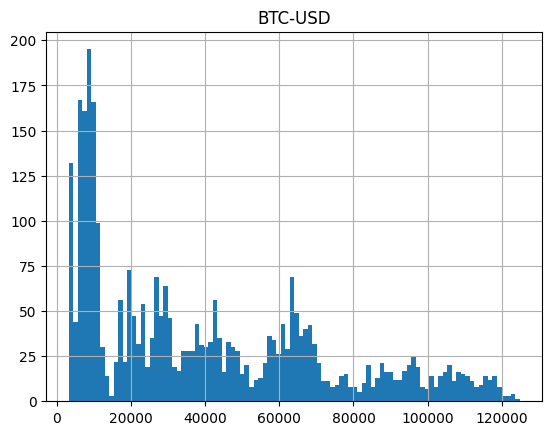

In [26]:
#Histograma Precio Ciere Bitcoin
btc.Close.hist(bins=100)

In [20]:
#Indice Fear and Greed -- Mide el miedl del mercado 

url = "https://api.alternative.me/fng/?date_format=%2701%2F01%2F2018%27&format=csv&limit=50000"
response = requests.get(url)

if response.status_code == 200:
    content = response.content.decode('utf-8')
    start = content.find("fng_value")
    csv_data = content[start:]
    # Leer el CSV desde el string
    df = pd.read_csv(io.StringIO(csv_data))
    # Renombrar columnas
    df = df.rename(columns={
        'fng_value': 'date',
        'fng_classification': 'fng_value',
        'date': 'fng_classification'
    })
    # Guardar el nuevo CSV
    df = df.iloc[:-5]
    df.to_csv("../Data/fear_greed.csv", index=False)
    print(df.head(20)) #Muestro los ultimos 20 datos 
else:
    print("Error:", response.status_code)

          date  fng_value fng_classification
0   23-08-2026       66.0              Greed
1   22-08-2026       71.0              Greed
2   21-08-2026       72.0              Greed
3   20-08-2026       62.0              Greed
4   19-08-2026       46.0               Fear
5   18-08-2026       41.0               Fear
6   17-08-2026       31.0               Fear
7   16-08-2026       34.0               Fear
8   15-08-2026       34.0               Fear
9   14-08-2026       29.0               Fear
10  13-08-2026       29.0               Fear
11  12-08-2026       27.0               Fear
12  11-08-2026       29.0               Fear
13  10-08-2026       30.0               Fear
14  09-08-2026       31.0               Fear
15  08-08-2026       30.0               Fear
16  07-08-2026       29.0               Fear
17  06-08-2026       25.0       Extreme Fear
18  05-08-2026       27.0               Fear
19  04-08-2026       25.0       Extreme Fear
